# 1) Data loading

In [1]:
import os 
os.chdir("..")

In [30]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from src.utils import get_file_path

In [3]:
dataset_path = get_file_path("data/raw/Ethereum_V3_Transactions.parquet")
df = pd.read_parquet(dataset_path)
df.head()


,BlockNumber,BlockHash,timeStamp,TxHash,Nonce,TransactionIndex,From,To,Value,gas,...,InputData,MethodID,FunctionName,ContractAddress,CumulativeGasUsed,TxReceiptStatus,GasUsed,Confirmations,isError,Timestamp
0,16496939,0x1f6273056cec650069aa9b057b11aa598ad5976b3798...,1674807887,0xa7b2a6f0161a0f7003261a8a05bcea5cc476ce30a446...,18,64,0x7fa5195595efe0dfbc79f03303448af3fbe4ea91,0x87870bca3f3fd6335c3f4ce8392d69350b4fa4e2,0.0,379433,...,0xa415bcad0000000000000000000000006b175474e890...,0xa415bcad,"borrow(address asset, uint256 amount, uint256 ...",,5354305,1,284023,4825694,0,2023-01-27 08:24:47
1,16497024,0x9073b8754ad895842593d17e4b2ede1bc4253ad3b16e...,1674808907,0xb94cf55e58dd837b5805051a74d2978401eb0ea697c7...,203,248,0x5115563fe64378f3a645c97e24c4c8d640a04c67,0x87870bca3f3fd6335c3f4ce8392d69350b4fa4e2,0.0,328874,...,0x617ba037000000000000000000000000a0b86991c621...,0x617ba037,"supply(address asset, uint256 amount, address ...",,26435328,1,246121,4825609,0,2023-01-27 08:41:47
2,16497086,0xe04871750c96f22747043d44a22a2505012150dd8fe2...,1674809651,0x216708847759e309be9cbb1001fa8f9fb77b777ab4ed...,12,187,0x7872c6a21d268004b85223a5661f92cc2ad92f51,0x87870bca3f3fd6335c3f4ce8392d69350b4fa4e2,0.0,350000,...,0x02c205f00000000000000000000000007f39c581f595...,0x02c205f0,"supplyWithPermit(address asset, uint256 amount...",,11245049,1,222583,4825547,0,2023-01-27 08:54:11
3,16497114,0xfd07afa8cd3a87f0c35a36d223e0b153ea0b1a3b1283...,1674809987,0x8e5799e9258d81dabd56034bd56505c96550e4c1b9f0...,908,60,0x2ceb5d4d3c325485d4d977c929504954ee92f194,0x87870bca3f3fd6335c3f4ce8392d69350b4fa4e2,0.0,87378,...,0x28530a47000000000000000000000000000000000000...,0x28530a47,setUserEMode(uint8 categoryId),,5584303,1,66196,4825519,0,2023-01-27 08:59:47
4,16497115,0x65a26109223a5092460c32a406130037960a16a68593...,1674809999,0xaad8647697f5b021934be76a2f691f7eb4edba49999d...,13,44,0x7872c6a21d268004b85223a5661f92cc2ad92f51,0x87870bca3f3fd6335c3f4ce8392d69350b4fa4e2,0.0,89442,...,0x28530a47000000000000000000000000000000000000...,0x28530a47,setUserEMode(uint8 categoryId),,27661372,1,67735,4825518,0,2023-01-27 08:59:59


# 2) Dataset overview


In [4]:
df.shape

(379784, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 379784 entries, 0 to 379783
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   BlockNumber        379784 non-null  str           
 1   BlockHash          379784 non-null  str           
 2   timeStamp          379784 non-null  int64         
 3   TxHash             379784 non-null  str           
 4   Nonce              379784 non-null  str           
 5   TransactionIndex   379784 non-null  str           
 6   From               379784 non-null  str           
 7   To                 379784 non-null  str           
 8   Value              379784 non-null  float64       
 9   gas                379784 non-null  str           
 10  GasPrice           379784 non-null  int64         
 11  InputData          379784 non-null  str           
 12  MethodID           379784 non-null  str           
 13  FunctionName       379784 non-null  str           
 14 

In [6]:
df.describe()

,timeStamp,Value,GasPrice,GasUsed,isError,Timestamp
count,3.797840e+05,3.797840e+05,3.797840e+05,3.797840e+05,379784.000000,379784
mean,1.712703e+09,3.502205e-07,1.984175e+10,2.913485e+05,0.009740,2024-04-09 22:45:33.053599232
min,1.674808e+09,0.000000e+00,4.851206e+08,2.100000e+04,0.000000,2023-01-27 08:24:47
25%,1.702098e+09,0.000000e+00,6.584059e+09,1.882348e+05,0.000000,2023-12-09 05:08:02
50%,1.716155e+09,0.000000e+00,1.404483e+10,2.165370e+05,0.000000,2024-05-19 21:43:11
75%,1.725038e+09,0.000000e+00,2.574411e+10,3.454335e+05,0.000000,2024-08-30 17:06:20
max,1.732896e+09,9.820000e-02,1.826346e+12,3.799283e+06,1.000000,2024-11-29 16:01:59
std,1.519852e+07,1.635047e-04,2.378340e+10,1.861093e+05,0.098209,NaN


In [8]:
# Columns by data type
string_columns = df.select_dtypes(include="str").columns.to_list()
integer_columns = df.select_dtypes(include="int").columns.to_list()
float_columns = df.select_dtypes(include="float").columns.to_list()
datetime_columns = df.select_dtypes(include="datetime").columns.to_list()

print("String columns:", len(string_columns), "columns:", string_columns)
print("Integer columns:", len(integer_columns), "columns:", integer_columns)
print("Float columns:", len(float_columns), "columns:", float_columns)
print("Datetime columns:", len(datetime_columns), "columns:", datetime_columns)


String columns: 15 columns: ['BlockNumber', 'BlockHash', 'TxHash', 'Nonce', 'TransactionIndex', 'From', 'To', 'gas', 'InputData', 'MethodID', 'FunctionName', 'ContractAddress', 'CumulativeGasUsed', 'TxReceiptStatus', 'Confirmations']
Integer columns: 4 columns: ['timeStamp', 'GasPrice', 'GasUsed', 'isError']
Float columns: 1 columns: ['Value']
Datetime columns: 1 columns: ['Timestamp']


# 3) Data quality checks


In [9]:
# Check for missing values
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


BlockNumber          0
BlockHash            0
timeStamp            0
TxHash               0
Nonce                0
TransactionIndex     0
From                 0
To                   0
Value                0
gas                  0
GasPrice             0
InputData            0
MethodID             0
FunctionName         0
ContractAddress      0
CumulativeGasUsed    0
TxReceiptStatus      0
GasUsed              0
Confirmations        0
isError              0
Timestamp            0
dtype: int64

In [10]:
#Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
#Check timestamp columns duplication 
print("Unique timeStamp values:", len(df["timeStamp"].unique()))
print("Unique Timestamp values:", len(df["Timestamp"].unique()))
if (df["timeStamp"] == df["Timestamp"].astype("int64")//10**9).all():
    print("timeStamp and Timestamp columns are identical.")
#Drop one of the timestamp columns
df.drop(columns=['timeStamp'], inplace=True)

Unique timeStamp values: 351787
Unique Timestamp values: 351787
timeStamp and Timestamp columns are identical.


In [24]:
df.shape

(379784, 20)

In [23]:
for column in df.columns: #Loop each column in DataFrame
    nunique = df[column].nunique()
    print(f"Column: {column}, Unique Values: {nunique}")

Column: BlockNumber, Unique Values: 351787
Column: BlockHash, Unique Values: 351787
Column: TxHash, Unique Values: 379784
Column: Nonce, Unique Values: 12236
Column: TransactionIndex, Unique Values: 626
Column: From, Unique Values: 41844
Column: To, Unique Values: 1
Column: Value, Unique Values: 7
Column: gas, Unique Values: 89505
Column: GasPrice, Unique Values: 356565
Column: InputData, Unique Values: 321160
Column: MethodID, Unique Values: 23
Column: FunctionName, Unique Values: 20
Column: ContractAddress, Unique Values: 1
Column: CumulativeGasUsed, Unique Values: 375646
Column: TxReceiptStatus, Unique Values: 2
Column: GasUsed, Unique Values: 95755
Column: Confirmations, Unique Values: 351786
Column: isError, Unique Values: 2
Column: Timestamp, Unique Values: 351787


# 4) Numeric distribution analysis


Numeric columns: Index(['Value', 'GasPrice', 'GasUsed', 'isError'], dtype='str')


array([[<Axes: title={'center': 'Value'}>,
        <Axes: title={'center': 'GasPrice'}>],
       [<Axes: title={'center': 'GasUsed'}>, <Axes: >]], dtype=object)

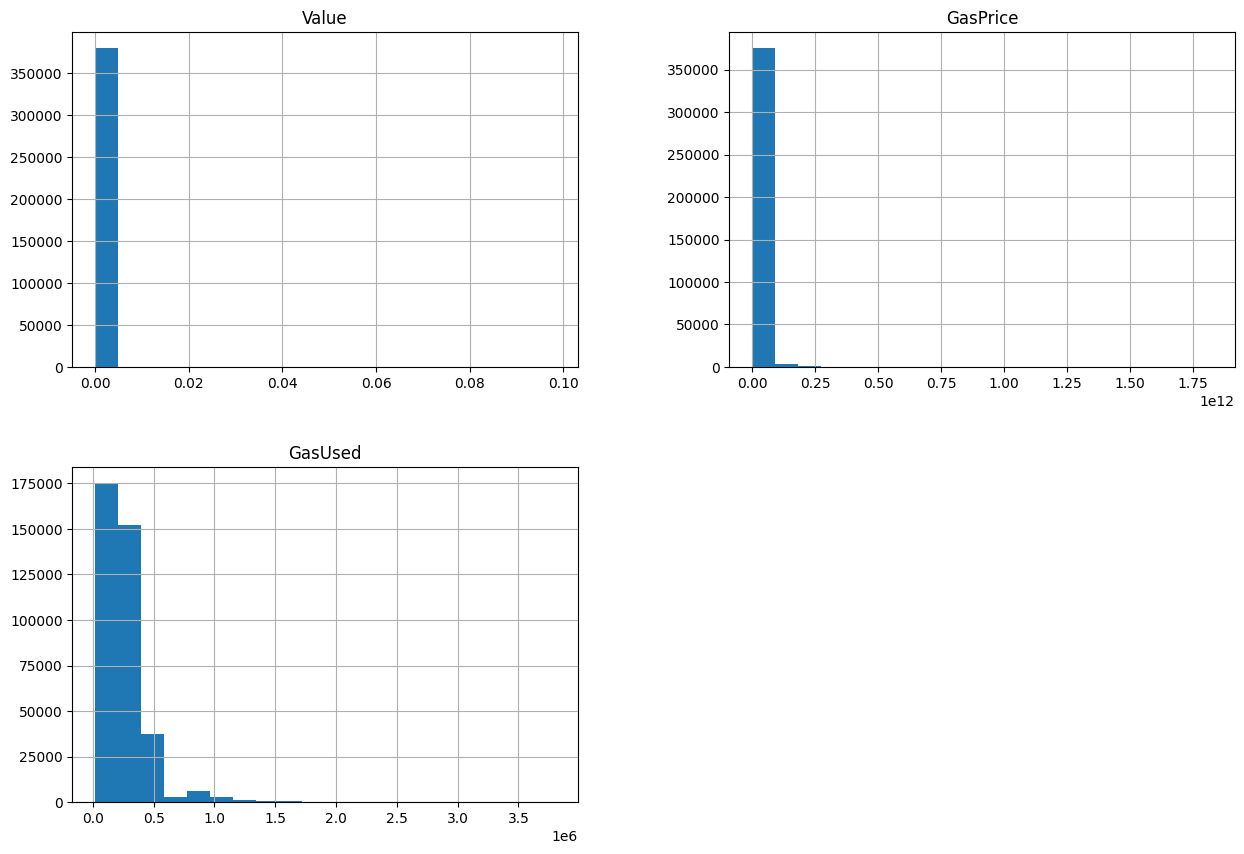

In [ ]:
# Raw histograms for numeric columns with more than 2 unique values
numeric_columns = df.select_dtypes(include="number").columns
print("Numeric columns:", numeric_columns)
hist_columns = [column for column in numeric_columns if df[column].nunique() > 2]
df[hist_columns].hist(bins=20, figsize=(15, 10))


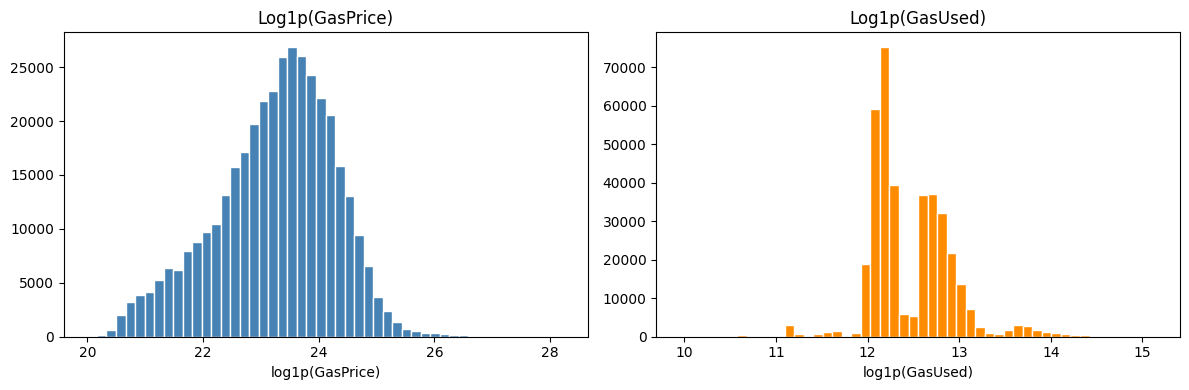

In [32]:
#Log transform skewed numeric columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log1p(df["GasPrice"]), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Log1p(GasPrice)")
axes[0].set_xlabel("log1p(GasPrice)")

axes[1].hist(np.log1p(df["GasUsed"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Log1p(GasUsed)")
axes[1].set_xlabel("log1p(GasUsed)")

plt.tight_layout()
plt.show()

- Raw histograms show strong right skew for both GasPrice and GasUsed, with long right tails and potential outliers.
- After log1p transformation, GasPrice becomes roughly unimodal and easier to interpret.
- GasUsed remains more irregular after transformation, suggesting heterogeneous transaction patterns and possible subgroups by function type.

## Boxplots of GasPrice and GasUsed

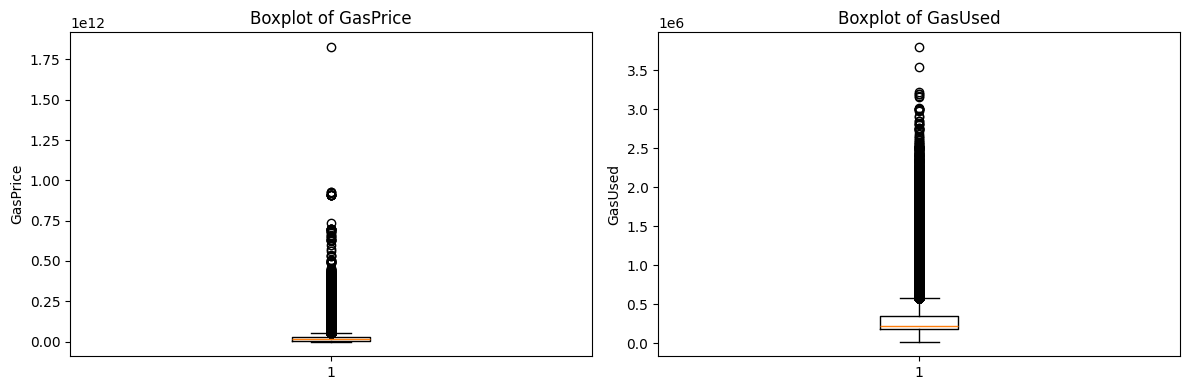

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df["GasPrice"])
axes[0].set_title("Boxplot of GasPrice")
axes[0].set_ylabel("GasPrice")

axes[1].boxplot(df["GasUsed"])
axes[1].set_title("Boxplot of GasUsed")
axes[1].set_ylabel("GasUsed")

plt.tight_layout()
plt.show()

- GasPrice and GasUsed show strong right skew with many high-end outliers on the original scale. 
- The central boxes are compressed near the lower range, indicating that most observations are relatively small compared with a long upper tail of extreme values.`

## Log-transformed boxplots of GasPrice and GasUsed

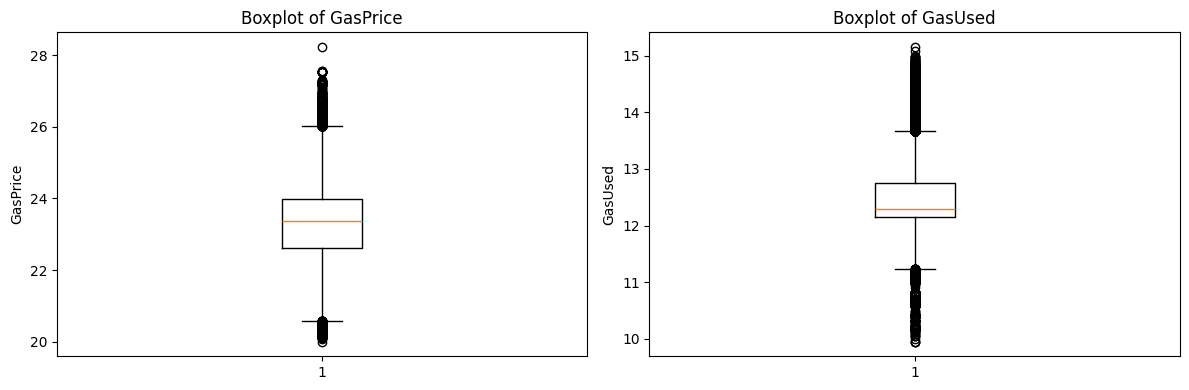

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(np.log1p(df["GasPrice"]))
axes[0].set_title("Boxplot of log1p(GasPrice)")
axes[0].set_ylabel("log1p(GasPrice)")

axes[1].boxplot(np.log1p(df["GasUsed"]))
axes[1].set_title("Boxplot of log1p(GasUsed)")
axes[1].set_ylabel("log1p(GasUsed)")

plt.tight_layout()
plt.show()


- After log1p transformation, both variables become much easier to inspect. 
- The central spread and median are now visible more clearly, while outliers remain present. GasPrice appears relatively unimodal with moderate spread, whereas GasUsed still shows a wider and more irregular upper tail, suggesting more heterogeneous transaction behavior.

# 5) Categorical and binary feature analysis


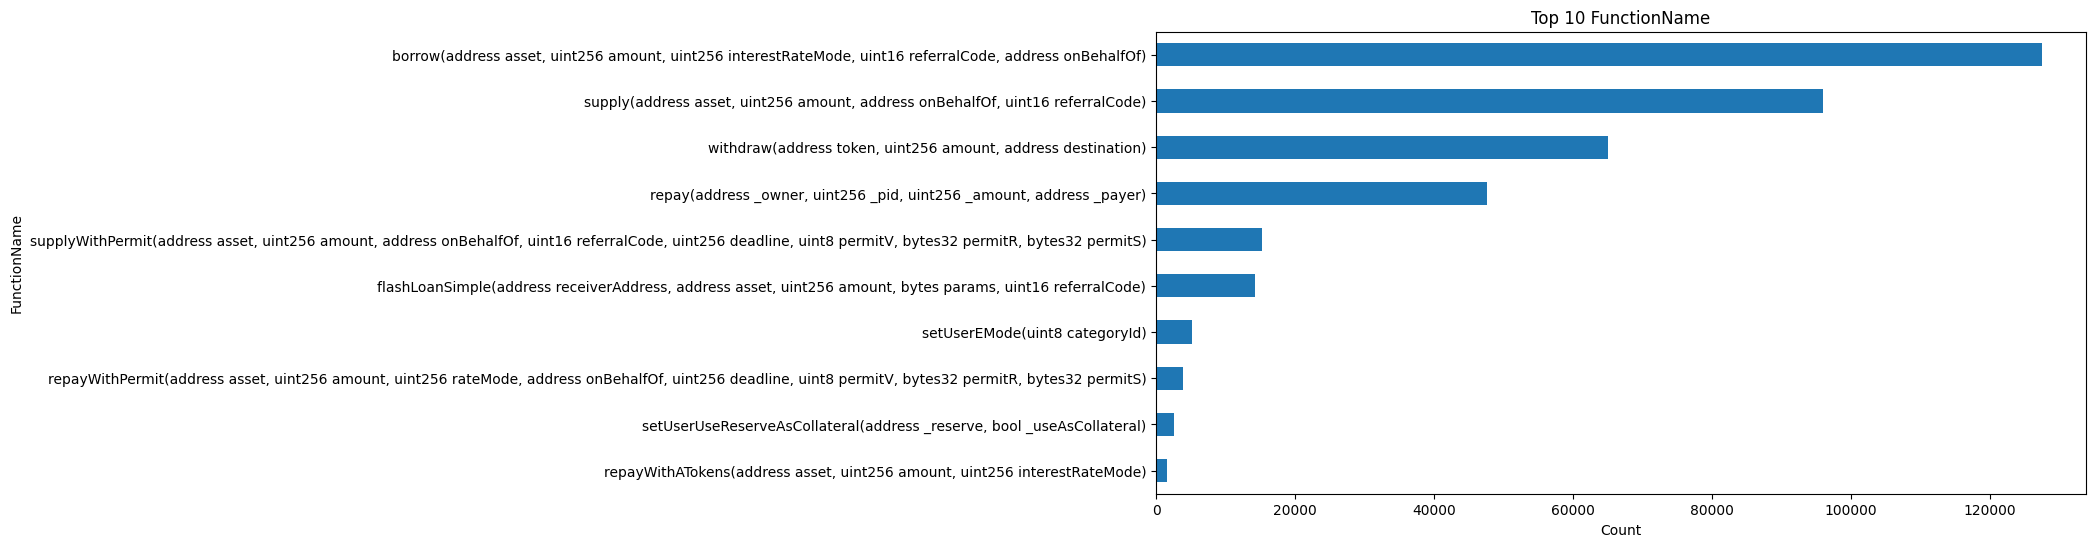

In [37]:
top10 = df["FunctionName"].value_counts().head(10).sort_values()

plt.figure(figsize=(12, 6))
top10.plot(kind="barh")
plt.title("Top 10 FunctionName")
plt.xlabel("Count")
plt.ylabel("FunctionName")
plt.show()

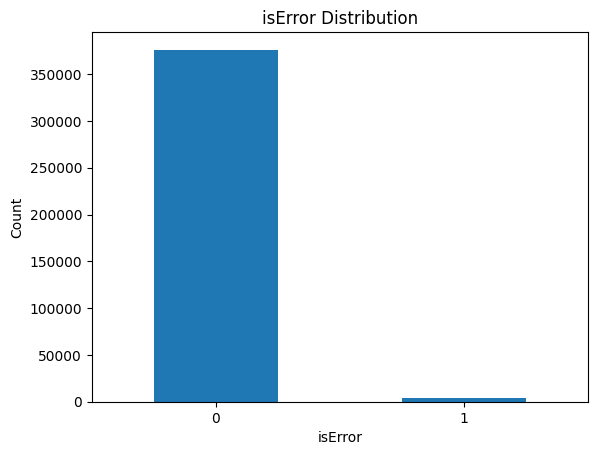

In [42]:
df["isError"].value_counts().sort_index().plot(kind="bar")
plt.title("isError Distribution")
plt.xlabel("isError")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

# 6) Dataset coverage and liquidation feasibility checks


In [44]:
print("Unique From wallets:", df["From"].nunique())
print("Unique To addresses:", df["To"].nunique())

Unique From wallets: 41844
Unique To addresses: 1


In [46]:
print("Timestamp min:", df["Timestamp"].min())
print("Timestamp max:", df["Timestamp"].max())
print("Number of days covered:", (df["Timestamp"].max() - df["Timestamp"].min()).days)

Timestamp min: 2023-01-27 08:24:47
Timestamp max: 2024-11-29 16:01:59
Number of days covered: 672


In [ ]:
liquidation = df[df["FunctionName"].str.startswith("liquidationCall", na=False)]
print("Liquidation rows:", len(liquidation))
print("Liquidation share (%):", round(len(liquidation) / len(df) * 100, 4))
print("Unique liquidation tx senders (From):", liquidation["From"].nunique())


Liquidation rows: 21


In [48]:
print("Top To addresses:")
print(df["To"].value_counts().head())
print("Empty FunctionName rows:", (df["FunctionName"] == "").sum())


Unique FunctionName values: <ArrowStringArray>
[                                                   'borrow(address asset, uint256 amount, uint256 interestRateMode, uint16 referralCode, address onBehalfOf)',
                                                                              'supply(address asset, uint256 amount, address onBehalfOf, uint16 referralCode)',
 'supplyWithPermit(address asset, uint256 amount, address onBehalfOf, uint16 referralCode, uint256 deadline, uint8 permitV, bytes32 permitR, bytes32 permitS)',
                                                                                                                              'setUserEMode(uint8 categoryId)',
                                                                                                'withdraw(address token, uint256 amount, address destination)',
                                                                                        'repay(address _owner, uint256 _pid, uint256 _amount, address _pa

# 7) Preliminary conclusion
- The dataset appears clean at the row level: no missing values, no duplicate rows, and the duplicate timestamp representation was removed.
- Transaction activity is concentrated in a small set of core Aave functions, while failed transactions remain rare.
- Liquidation transactions are present but extremely rare relative to total rows, which creates severe class imbalance for any liquidation-based label.
- The `To` address distribution is highly concentrated and should be interpreted as protocol-specific routing rather than diverse destination behavior.
- `Liquidation rows` represent liquidation transactions, not necessarily the number of unique borrower wallets liquidated, since the true liquidated user may be encoded inside `InputData`.
- This raw dataset is suitable for early validation and exploratory analysis, but may be insufficient for a robust MVP if the liquidation label remains the sole positive target.
